Loaded CiteSeer: N=3327, F=3703, C=6
Total directed edges: 9104
Undirected edges (unique): 4552
Train/Val/Test: 120, 500, 1000
Epoch 001 | Loss 1.7990 | Train 0.0917 | Val 0.1240 | Test 0.1520
Epoch 010 | Loss 1.7587 | Train 0.3417 | Val 0.1820 | Test 0.2220
Epoch 020 | Loss 1.6767 | Train 0.6917 | Val 0.3580 | Test 0.3960
Epoch 030 | Loss 1.5811 | Train 0.8250 | Val 0.5240 | Test 0.5280
Epoch 040 | Loss 1.4688 | Train 0.8583 | Val 0.5940 | Test 0.6250
Epoch 050 | Loss 1.3393 | Train 0.8833 | Val 0.6360 | Test 0.6600
Epoch 060 | Loss 1.1993 | Train 0.9167 | Val 0.6640 | Test 0.6870
Epoch 070 | Loss 1.0572 | Train 0.9250 | Val 0.6680 | Test 0.6970
Epoch 080 | Loss 0.9217 | Train 0.9250 | Val 0.6880 | Test 0.7040
Epoch 090 | Loss 0.7994 | Train 0.9250 | Val 0.6920 | Test 0.7040
Epoch 100 | Loss 0.6931 | Train 0.9417 | Val 0.6980 | Test 0.7040
Epoch 110 | Loss 0.6030 | Train 0.9417 | Val 0.7080 | Test 0.7100
Epoch 120 | Loss 0.5277 | Train 0.9417 | Val 0.7080 | Test 0.7040
Epoch 130 | Los

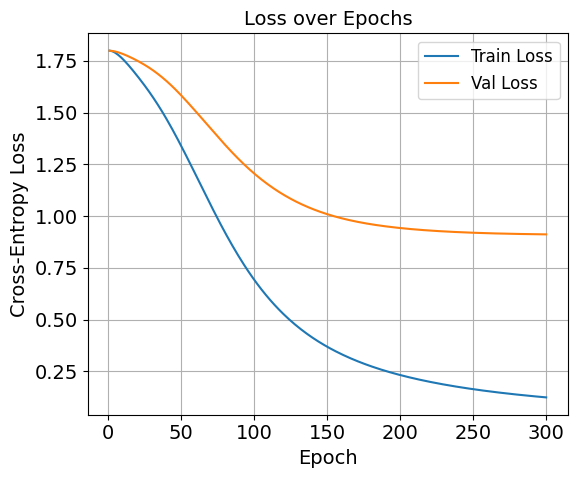

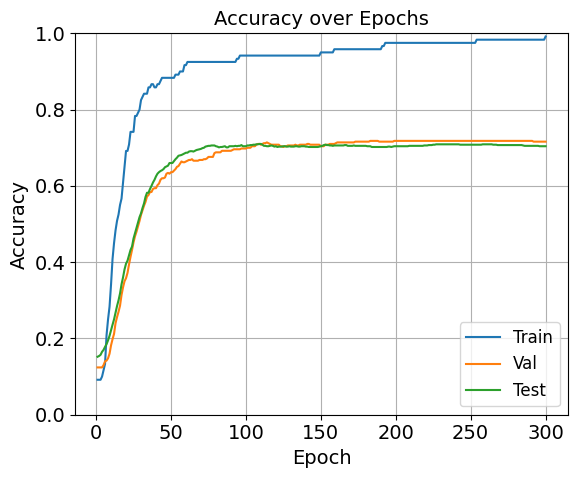

In [15]:
import numpy as np
import os, math, time
import torch
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt

NPZ_PATH = "citeseer_np.npz"

def export_citeseer_npz(out_path="citeseer_np.npz"):
    dataset = Planetoid(root="data/CiteSeer", name="CiteSeer")
    data = dataset[0]
    N = data.num_nodes
    adj = torch.zeros((N, N))
    adj[data.edge_index[0], data.edge_index[1]] = 1
    adj = adj.numpy().astype(np.float32)
    np.savez(out_path,
             adj=adj,
             features=data.x.numpy().astype(np.float32),
             labels=data.y.numpy().astype(int),
             train_idx=np.where(data.train_mask.numpy())[0],
             val_idx=np.where(data.val_mask.numpy())[0],
             test_idx=np.where(data.test_mask.numpy())[0])
    print(f"Exported dataset to {out_path}")

if not os.path.exists(NPZ_PATH):
    export_citeseer_npz(NPZ_PATH)


data = np.load(NPZ_PATH, allow_pickle=True)
A = data["adj"].astype(np.float32)
X = data["features"].astype(np.float32)
y = data["labels"].astype(int)
train_idx, val_idx, test_idx = data["train_idx"], data["val_idx"], data["test_idx"]
C = int(y.max() + 1)

print(f"Loaded CiteSeer: N={X.shape[0]}, F={X.shape[1]}, C={C}")
directed_edges = int(A.sum())
undirected_edges = directed_edges // 2
print("Total directed edges:", directed_edges)
print("Undirected edges (unique):", undirected_edges)
print(f"Train/Val/Test: {len(train_idx)}, {len(val_idx)}, {len(test_idx)}")


def normalize_adj(A):
    A = A + np.eye(A.shape[0], dtype=np.float32)
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    return D_inv_sqrt @ A @ D_inv_sqrt

def one_hot(y, C):
    Y = np.zeros((len(y), C), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1
    return Y

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

def cross_entropy(pred, y_onehot):
    m = pred.shape[0]
    loss = -np.sum(y_onehot * np.log(np.clip(pred, 1e-12, 1.0))) / m
    grad = (pred - y_onehot) / m
    return loss, grad

A_hat = normalize_adj(A)
Y_onehot = one_hot(y, C)


class GCN:
    def __init__(self, in_dim, hidden_dim, out_dim, seed=42):
        rng = np.random.RandomState(seed)
        self.W0 = rng.randn(in_dim, hidden_dim).astype(np.float32) * np.sqrt(2/in_dim)
        self.b0 = np.zeros(hidden_dim, dtype=np.float32)
        self.W1 = rng.randn(hidden_dim, out_dim).astype(np.float32) * np.sqrt(2/hidden_dim)
        self.b1 = np.zeros(out_dim, dtype=np.float32)

    def forward(self, X, A_hat):
        # first layer: linear -> ReLU
        self.H1_pre = A_hat @ X @ self.W0 + self.b0  # (N x h)
        self.H1 = np.maximum(0, self.H1_pre)         # ReLU
        # second layer: produce logits
        self.Z = A_hat @ self.H1 @ self.W1 + self.b1 # (N x C)
        self.P = softmax(self.Z)
        return self.P

    def gradients(self, X, A_hat, Y_onehot, train_mask, wd=5e-4):
        # train_mask: array of train indices
        m = len(train_mask)
        mask = np.zeros(X.shape[0], dtype=np.float32)
        mask[train_mask] = 1.0
        # broadcast mask to (N x C)
        dZ = (self.P - Y_onehot) * mask[:, None] / m
        # gradients for W1, b1
        # dW1 = H1.T @ (A_hat.T @ dZ)  -> A_hat symmetric so A_hat.T == A_hat
        dW1 = (self.H1.T @ (A_hat.T @ dZ)) + wd * self.W1
        db1 = dZ.sum(axis=0)
        # backprop into H1
        dH1 = (A_hat.T @ dZ) @ self.W1.T
        # through ReLU
        dH1[self.H1_pre <= 0] = 0
        # gradients for W0, b0
        dW0 = (X.T @ (A_hat.T @ dH1)) + wd * self.W0
        db0 = dH1.sum(axis=0)
        return [dW0, db0, dW1, db1]


class SGD_Momentum:
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0.0):
        self.params = params
        self.lr = lr
        self.mom = momentum
        self.wd = weight_decay
        self.v = [np.zeros_like(p) for p in params]

    def step(self, grads):
        for i, (p, g) in enumerate(zip(self.params, grads)):
            if g is None:
                continue
            # weight decay applied in gradients already, but keep this in case you don't pass wd in grads
            if self.wd != 0.0:
                g = g + self.wd * p
            self.v[i] = self.mom * self.v[i] + g
            p -= self.lr * self.v[i]


# instantiate model and optimizer
model = GCN(in_dim=X.shape[1], hidden_dim=128, out_dim=C)
params = [model.W0, model.b0, model.W1, model.b1]
optimizer = SGD_Momentum(params, lr=0.01, momentum=0.9, weight_decay=5e-4)

best_val = -1.0
best_state = None
epochs = 300

# Histories for plotting
loss_history = []
val_loss_history=[]
train_acc_history = []
val_acc_history = []
test_acc_history = []

for epoch in range(1, epochs + 1):
    P = model.forward(X, A_hat)
    loss, _ = cross_entropy(P[train_idx], Y_onehot[train_idx])
    val_loss, _ = cross_entropy(P[val_idx], Y_onehot[val_idx])
    # compute gradients on the training set
    grads = model.gradients(X, A_hat, Y_onehot, train_idx, wd=5e-4)
    optimizer.step(grads)

    preds = np.argmax(P, axis=1)
    train_acc = float(np.mean(preds[train_idx] == y[train_idx]))
    val_acc = float(np.mean(preds[val_idx] == y[val_idx]))
    test_acc = float(np.mean(preds[test_idx] == y[test_idx]))

    # record history
    loss_history.append(float(loss))
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    test_acc_history.append(test_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_state = [p.copy() for p in params]

    # print status every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Train {train_acc:.4f} | Val {val_acc:.4f} | Test {test_acc:.4f}")

# Restore best weights
if best_state is not None:
    for p, best_p in zip(params, best_state):
        p[:] = best_p

print("Training complete! Best Val:", best_val)

plt.rcParams.update({'font.size': 14})

# Loss plot
plt.figure(figsize=(6,5))
plt.plot(range(1, epochs+1), loss_history, label="Train Loss", linewidth=1.5)
plt.plot(range(1, epochs+1), val_loss_history, label="Val Loss", linewidth=1.5)
plt.title("Loss over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Cross-Entropy Loss", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_all.png", dpi=150)

# Accuracy plot (train / val / test)
plt.figure(figsize=(6,5))
plt.plot(range(1, epochs+1), train_acc_history, label="Train", linewidth=1.5)
plt.plot(range(1, epochs+1), val_acc_history, label="Val", linewidth=1.5)
plt.plot(range(1, epochs+1), test_acc_history, label="Test", linewidth=1.5)
plt.title("Accuracy over Epochs", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0.0, 1.0)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy.png", dpi=150)
print("Saved accuracy plot to accuracy.png")

plt.show()
